# ITAI 4374 Neuroscience as a Model for AI
# Professor Patricia McManus
# Hoang Dinh
# L02 Cortical Column Voting Simulation

## Introduction

Understanding how the brain forms reliable perceptions from incomplete and noisy sensory information is a central challenge in neuroscience and artificial intelligence. The Thousand Brains Theory proposes that intelligence emerges not from a single centralized processor, but from many independent cortical columns that each build their own models of the world and cooperate through communication and consensus. Rather than relying on a top-down controller, perception arises from a distributed voting process across these columns.

In this assignment, a simplified simulation of cortical column voting is implemented to explore how distributed representations can be combined to reach a shared interpretation of sensory input. Multiple independent “columns” receive partial and noisy information about an object, generate competing hypotheses, and contribute votes toward a global consensus. By observing how agreement emerges over time, this lab connects abstract neuroscience theory to a concrete computational model.

Through a series of controlled experiments, this simulation highlights key trade-offs in consensus-based systems, including the balance between speed and accuracy, robustness to noise, and the effects of scaling the number of columns. While the model is intentionally simplified compared to real biological systems, it provides valuable insight into the strengths and limitations of distributed intelligence and offers a hands-on way to reason about how collective decision-making may occur in the brain.

## Python Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# Set seed for reproducibility
np.random.seed(42)
# Define objects our system can recognize
OBJECTS = ["cup", "ball", "book", "phone", "apple"]
NUM_OBJECTS = len(OBJECTS)
print("Setup complete!")
print("Objects:", OBJECTS)


Setup complete!
Objects: ['cup', 'ball', 'book', 'phone', 'apple']


## Implementation Tasks

### Task 1: Create Sensory Input

In [7]:
def create_sensory_input(true_object, num_columns, noise_level=0.3):
  """
  Creates evidence matrix for all columns.
  Parameters:
  - true_object: int, index of the actual object (0 to 4)
  - num_columns: int, number of columns to simulate
  - noise_level: float, amount of random noise (0 to 1)
  Returns:
  - evidence: numpy array of shape (num_columns, NUM_OBJECTS)
  """
  # TODO 1: Create matrix filled with random noise
  # Hint: Use np.random.uniform(low, high, size)
  # Size should be (num_columns, NUM_OBJECTS)
  evidence = np.random.uniform(
    low=0.0,
    high=noise_level,
    size=(num_columns, NUM_OBJECTS)
  ) # YOUR CODE HERE

  # TODO 2: Add signal for the true object
  # Loop through each column and add random value between 0.5-1.0
  # to the true_object index
  for col in range(num_columns):
    signal = np.random.uniform(0.5, 1.0) # YOUR CODE: random value 0.5 to 1.0
    evidence[col, true_object] += signal

  # TODO 3: Normalize each row to sum to 1
  # Hint: Divide each row by its sum
  # Use axis=1 and keepdims=True
  row_sums = evidence.sum(axis=1, keepdims=True) # YOUR CODE HERE
  evidence = evidence / row_sums
  return evidence


Testing Function

In [8]:
# Test create_sensory_input
true_object = 0 # "cup"
num_columns = 6

evidence = create_sensory_input(true_object, num_columns, noise_level=0.3)

print(f"True object: {OBJECTS[true_object]}")
print(f"Evidence shape: {evidence.shape}")
print("\nEach column's evidence:")
for i in range(num_columns):
  best = OBJECTS[np.argmax(evidence[i])]
  conf = np.max(evidence[i]) * 100
  print(f" Column {i}: {best} ({conf:.1f}%)")

True object: cup
Evidence shape: (6, 5)

Each column's evidence:
 Column 0: cup (55.6%)
 Column 1: cup (48.5%)
 Column 2: cup (45.0%)
 Column 3: cup (68.9%)
 Column 4: cup (75.6%)
 Column 5: cup (73.7%)


### Task 2: Initialize Beliefs

In [9]:
def initialize_beliefs(evidence):
  """Initialize beliefs from sensory evidence."""
  return evidence.copy() # YOUR CODE: return a copy of evidence

Testing Function

In [10]:
beliefs = initialize_beliefs(evidence)
print("Beliefs initialized!")
print(f"Shape: {beliefs.shape}")
print(f"Same as evidence? {np.allclose(beliefs, evidence)}")

Beliefs initialized!
Shape: (6, 5)
Same as evidence? True


### Task 3: The Voting Mechanism


In [12]:
def voting_round(beliefs, evidence, vote_weight=0.3):
  """
  One round of voting among columns.
  Parameters:
  - beliefs: current beliefs, shape (num_columns, NUM_OBJECTS)
  - evidence: original sensory evidence (doesn't change)
  - vote_weight: float 0-1, how much to trust neighbors
  Returns:
  - new_beliefs: updated beliefs after voting
  """
  num_columns = beliefs.shape[0]
  new_beliefs = np.zeros_like(beliefs)
  for col in range(num_columns):
    # TODO 1: Calculate this column's own contribution
    # Hint: (1 - vote_weight) * evidence[col]
    own_contribution = (1 - vote_weight) * evidence[col] # YOUR CODE

    # TODO 2: Get beliefs from OTHER columns (not this one)
    # Hint: Use list comprehension to get indices != col
    # Then index into beliefs
    other_indices = [i for i in range(num_columns) if i != col]
    other_beliefs = beliefs[other_indices] # YOUR CODE: beliefs[other_indices]

    # TODO 3: Calculate average vote from others
    # Hint: Use .mean(axis=0) to average across columns
    avg_vote = other_beliefs.mean(axis=0) # YOUR CODE

    # TODO 4: Calculate vote contribution
    vote_contribution = vote_weight * avg_vote # YOUR CODE

    # TODO 5: Combine own + vote contributions
    new_beliefs[col] = own_contribution + vote_contribution # YOUR CODE

  # TODO 6: Normalize rows
  row_sums = new_beliefs.sum(axis=1, keepdims=True)
  new_beliefs = new_beliefs / row_sums # YOUR CODE

  return new_beliefs


Testing Function

In [16]:
# Test voting_round
print("Before voting:")
for i in range(3):
    print(
        f" Col {i}: {OBJECTS[np.argmax(beliefs[i])]} "
        f"({np.max(beliefs[i]) * 100:.1f}%)"
    )

new_beliefs = voting_round(beliefs, evidence, vote_weight=0.3)

print("\nAfter 1 voting round:")
for i in range(3):
    print(
        f" Col {i}: {OBJECTS[np.argmax(new_beliefs[i])]} "
        f"({np.max(new_beliefs[i]) * 100:.1f}%)"
    )

Before voting:
 Col 0: cup (55.6%)
 Col 1: cup (48.5%)
 Col 2: cup (45.0%)

After 1 voting round:
 Col 0: cup (57.6%)
 Col 1: cup (53.1%)
 Col 2: cup (50.8%)


### Task 4: Run Until Consensus

In [17]:
# Example: checking consensus
predictions = np.argmax(beliefs, axis=1) # Best guess per column
# predictions might be [0, 0, 0, 2, 0, 0] - most say object 0
# Count votes for each object
vote_counts = np.bincount(predictions, minlength=NUM_OBJECTS)
# vote_counts = [5, 0, 1, 0, 0] - object 0 has 5 votes
# Find most common and calculate agreement
most_common = vote_counts.argmax() # = 0
agreement = (predictions == most_common).mean() # = 5/6 = 0.833

In [18]:
def run_voting(evidence, max_iterations=20, vote_weight=0.3, consensus_threshold=0.9):
  """
  Run voting until consensus or max iterations.
  Returns: (history, final_object, final_confidence, iterations_used)
  """

  # TODO 1: Initialize beliefs
  beliefs = initialize_beliefs(evidence) # YOUR CODE

  # TODO 2: Start history list with initial beliefs
  history = [beliefs.copy()]
  for iteration in range(max_iterations):
    # TODO 3: Do one voting round
    beliefs = voting_round(beliefs, evidence, vote_weight=vote_weight) # YOUR CODE

    # TODO 4: Add to history
    history.append(beliefs.copy()) # YOUR CODE

    # TODO 5: Check consensus
    predictions = np.argmax(beliefs, axis=1)
    vote_counts = np.bincount(predictions, minlength=NUM_OBJECTS)
    most_common = vote_counts.argmax()
    agreement = (predictions == most_common).mean() # YOUR CODE: fraction that agree

    # TODO 6: Break if consensus reached
    if agreement >= consensus_threshold:
      print(f"Consensus at iteration {iteration + 1}!")
      break

  # Calculate final result
  final_votes = beliefs.mean(axis=0) # Average across columns
  final_object = final_votes.argmax() # YOUR CODE: which object won?
  final_confidence = final_votes[final_object] # YOUR CODE: confidence in winner
  iterations_used = len(history) - 1

  return history, final_object, final_confidence, iterations_used


Testing Function

In [19]:
# Test run_voting
np.random.seed(42)
evidence = create_sensory_input(true_object=0, num_columns=6,
noise_level=0.3)
history, result, confidence, iters = run_voting(evidence)
print(f"Result: {OBJECTS[result]}")
print(f"Confidence: {confidence*100:.1f}%")
print(f"Iterations: {iters}")
print(f"Correct? {'Yes!' if result == 0 else 'No'}")

Consensus at iteration 1!
Result: cup
Confidence: 61.2%
Iterations: 1
Correct? Yes!


### Task 5: Visualization

In [23]:
def visualize_consensus(history, true_object):
  """Visualize how consensus emerges."""
  # Calculate average confidence per object at each iteration
  # history is a list of belief matrices
  # We need: for each time step, average confidence for each object
  avg_confidence = np.array([h.mean(axis=0) for h in history])

  # Shape: (num_iterations, NUM_OBJECTS)
  # TODO 1: Calculate agreement at each time step
  agreement_over_time = []

  for h in history:
    predictions = np.argmax(h, axis=1)
    counts = np.bincount(predictions, minlength=NUM_OBJECTS)
    agreement = counts.max() / len(predictions) # YOUR CODE: max votes / total columns
    agreement_over_time.append(agreement)

  # Create figure with 2 subplots
  fig, axes = plt.subplots(1, 2, figsize=(12, 4))

  # TODO 2: Plot 1 - Confidence over time
  ax1 = axes[0]
  for obj_idx in range(NUM_OBJECTS):
    # Make true object bold, others dashed
    if obj_idx == true_object:
      style = '-'
      width = 3
    else:
      style = '--'
      width = 1
    ax1.plot(avg_confidence[:, obj_idx], style, linewidth=width, label=OBJECTS[obj_idx])

  ax1.set_xlabel('Voting Round')
  ax1.set_ylabel('Average Confidence')
  ax1.set_title('Confidence Evolution')
  ax1.legend()
  ax1.set_ylim(0, 1)
  ax1.grid(True, alpha=0.3)

  # TODO 3: Plot 2 - Agreement over time
  ax2 = axes[1]
  ax2.plot(agreement_over_time, 'b-', linewidth=2, marker='o')
  ax2.axhline(y=0.9, color='r', linestyle='--', label='Threshold')
  ax2.set_xlabel('Voting Round')
  ax2.set_ylabel('Column Agreement')
  ax2.set_title('Consensus Emergence')
  ax2.legend()
  ax2.set_ylim(0, 1.05)
  ax2.grid(True, alpha=0.3)

  plt.tight_layout()
  plt.savefig('consensus_plot.png', dpi=150)
  plt.show()
  print("Plot saved as consensus_plot.png")

Testing Function

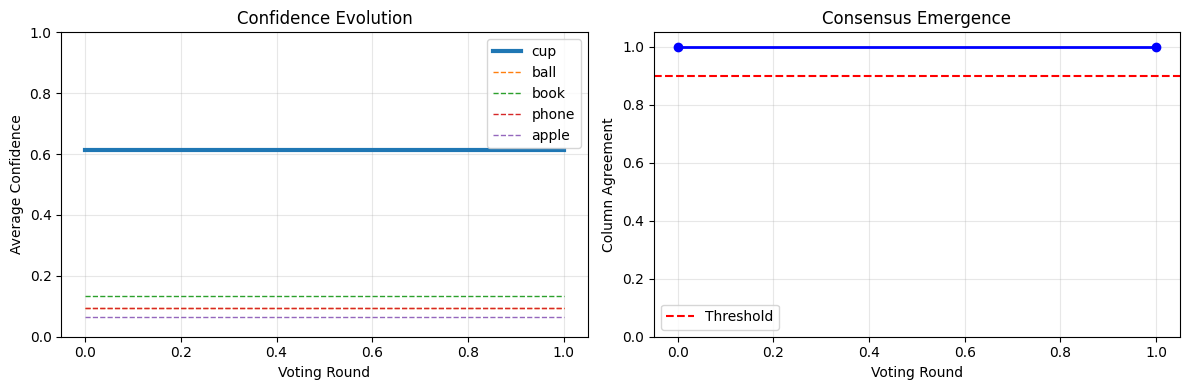

Plot saved as consensus_plot.png


In [24]:
# Create visualization
visualize_consensus(history, true_object=0)

## Required Experiments
### Experiment 1: High Noise

EXPERIMENT 1: HIGH NOISE
Consensus at iteration 1!
Result: cup
Confidence: 42.3%
Iterations: 1
Correct? Yes


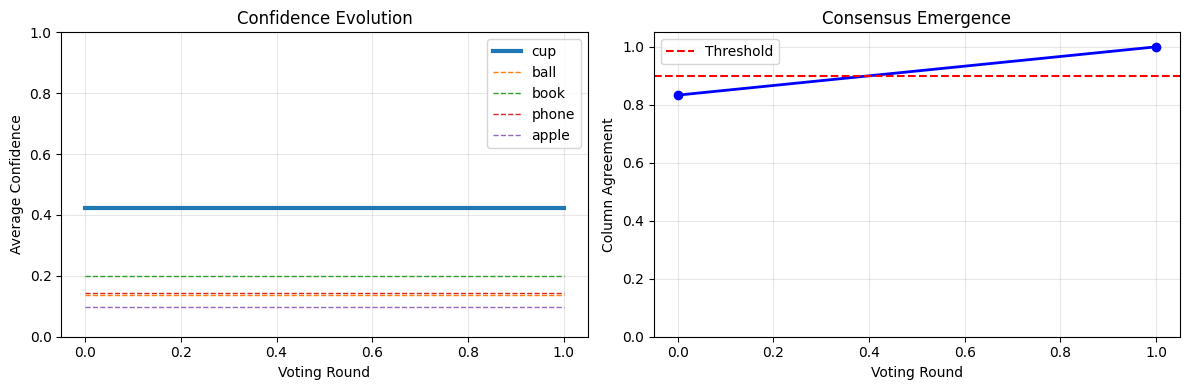

Plot saved as consensus_plot.png


In [26]:
# EXPERIMENT 1: High Noise
print("="*50)
print("EXPERIMENT 1: HIGH NOISE")
print("="*50)

np.random.seed(42) # Reset seed for fair comparison
evidence_noisy = create_sensory_input(
  true_object=0,
  num_columns=6,
  noise_level=0.8 # <-- Changed from 0.3
)

history_noisy, result_noisy, conf_noisy, iters_noisy = run_voting(evidence_noisy)

print(f"Result: {OBJECTS[result_noisy]}")
print(f"Confidence: {conf_noisy*100:.1f}%")
print(f"Iterations: {iters_noisy}")
print(f"Correct? {'Yes' if result_noisy == 0 else 'NO - WRONG ANSWER'}")

# Visualize
visualize_consensus(history_noisy, true_object=0)


**Observations:**

**Was the result correct?**

Yes

**How did confidence compare to the original (0.3 noise)?**

The confidence is now lower (42.3% compared to 61.2%)

**Did it take more/fewer iterations?**

No. It took same iteration (1)

**How did the visualization look different?**

The confidence plot showed flatter and more overlapping lines across objects, with no object strongly dominating early on. The agreement plot jumped quickly to the consensus threshold, but without a corresponding rise in confidence. This highlights a key trade-off: fast consensus does not necessarily imply high certainty, especially in noisy environments.

### Experiment 2: More Columns

EXPERIMENT 2: MORE COLUMNS
Consensus at iteration 1!
Result: cup
Confidence: 62.8%
Iterations: 1

Comparison to original (6 columns):
 6 columns: 61.2% confidence
 20 columns: 62.8% confidence


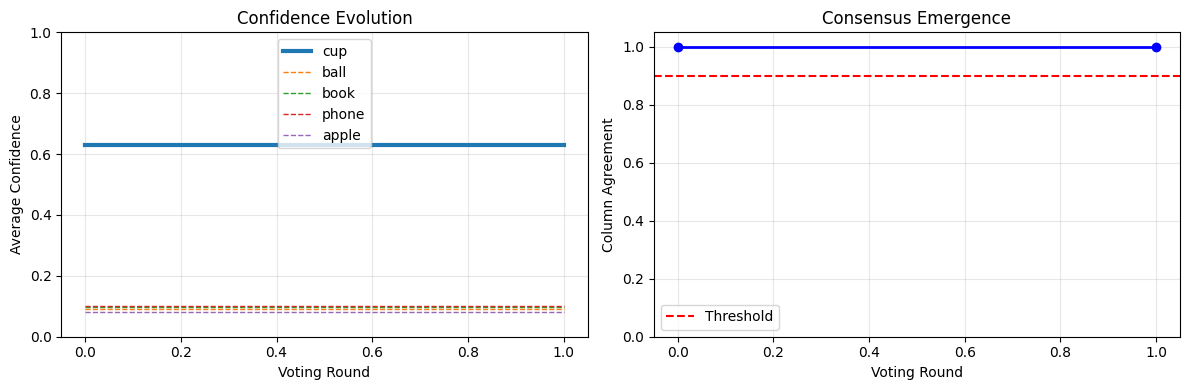

Plot saved as consensus_plot.png


In [28]:
# EXPERIMENT 2: More Columns
print("="*50)
print("EXPERIMENT 2: MORE COLUMNS")
print("="*50)

np.random.seed(42)
evidence_many = create_sensory_input(
  true_object=0,
  num_columns=20, # <-- Changed from 6
  noise_level=0.3
)

history_many, result_many, conf_many, iters_many = run_voting(evidence_many)

print(f"Result: {OBJECTS[result_many]}")
print(f"Confidence: {conf_many*100:.1f}%")
print(f"Iterations: {iters_many}")
print("\nComparison to original (6 columns):")
print(f" 6 columns: {confidence*100:.1f}% confidence")
print(f" 20 columns: {conf_many*100:.1f}% confidence")

visualize_consensus(history_many, true_object=0)

**Observations**

**Was confidence higher with more columns?**

Yes (slightly). Confidence increased from 61.2% (6 columns) to 62.8% (20 columns)

**Did it converge faster or slower?**

No. It took same iteration (1)

**The brain has ~150,000 columns. What might be the advantage?**

With a huge number of columns, the brain can average out noise and errors much more effectively. More independent “votes” can make perception more robust and stable, especially when sensory input is incomplete or noisy. It also allows different columns to specialize (different features, contexts, viewpoints), so the overall system can reach accurate consensus across many situations—not just simple cases like this simulation.

### Experiment 3: Vote Weight Comparison

In [30]:
# EXPERIMENT 3: Vote Weight Comparison
print("="*50)
print("EXPERIMENT 3: VOTE WEIGHT")
print("="*50)

weights_to_test = [0.1, 0.3, 0.5, 0.7, 0.9]
results = []

for w in weights_to_test:
  np.random.seed(42) # Same starting point each time
  ev = create_sensory_input(0, 6, noise_level=0.4)
  _, res, conf, iters = run_voting(ev, vote_weight=w)
  correct = "Yes" if res == 0 else "No"
  results.append((w, OBJECTS[res], conf, iters, correct))

print(f"{'Weight':<8} {'Result':<8} {'Conf':<10} {'Iters':<8} {'Correct'}")

print("-"*45)

for w, obj, conf, iters, correct in results:
  print(f"{w:<8} {obj:<8} {conf*100:>5.1f}% {iters:<8} {correct}")


EXPERIMENT 3: VOTE WEIGHT
Consensus at iteration 1!
Consensus at iteration 1!
Consensus at iteration 1!
Consensus at iteration 1!
Consensus at iteration 1!
Weight   Result   Conf       Iters    Correct
---------------------------------------------
0.1      cup       55.4% 1        Yes
0.3      cup       55.4% 1        Yes
0.5      cup       55.4% 1        Yes
0.7      cup       55.4% 1        Yes
0.9      cup       55.4% 1        Yes


**Observations:**

**Which weight gave the best results?**

They were all tied. Every weight (0.1–0.9) produced the correct object (cup), the same confidence (55.4%), and the same iterations (1).

**What happened with weight = 0.1 (barely listening to neighbors)?**

In this experiment, it didn’t change the outcome. Columns relied mostly on their own evidence, but they still reached consensus immediately and correctly—so the system behaved about the same as other weights under these conditions.

**What happened with weight = 0.9 (almost ignoring own evidence)?**

it didn’t change the outcome here. Even with heavy neighbor influence, the average vote still supported the correct object strongly enough that consensus was reached in one round with the same confidence.

**What trade-off is vote_weight balancing?**

vote_weight balances independence vs. social influence:

Lower values favor trusting local sensory evidence (often more robust to “groupthink,” but can converge slower).

Higher values favor following the group average (often faster convergence, but higher risk of converging confidently to the wrong answer if the group starts off biased or noisy).

## Analysis & Reflection

### Experiment Analysis

#### Question 1: Effects of Noise (Experiment 1)

Based on your high-noise experiment:

**How did noise affect accuracy and confidence?**

High noise did not reduce accuracy in this experiment—the system still correctly identified the object as cup. However, it significantly reduced confidence. The final confidence dropped to about 42.3%, indicating that although the columns agreed on the correct answer, their beliefs were much less certain due to noisy sensory input.

**Why does noise make consensus harder? (Think about what each column "sees")**

Noise makes consensus harder because each column receives less reliable and more ambiguous evidence. Instead of strongly favoring the true object, the sensory input is spread across multiple objects, increasing uncertainty. When individual columns are unsure or partially misled, their votes are weaker and less consistent, which reduces the strength of the group’s overall agreement.

**Did the system still work? What does this suggest about robustness?**

Yes, the system still worked—it reached consensus quickly and selected the correct object despite high noise. This suggests the voting mechanism is robust to a certain level of noise, since combining multiple imperfect perspectives can still produce the correct result. However, the low confidence shows that robustness has limits, and higher noise increases the risk of uncertain or incorrect consensus.

#### Question 2: Number of Columns (Experiment 2)

Based on your many-columns experiment:

**Did more columns improve performance? How?**

Yes, adding more columns slightly improved performance. With 20 columns, the system reached a higher confidence (62.8%) compared to 6 columns (61.2%), while still converging in the same number of iterations. More columns provide more independent sensory perspectives, which helps average out random noise and small errors in individual columns’ evidence.

**The brain has ~150,000 cortical columns. What advantage might this provide?**

Having such a large number of cortical columns allows the brain to be highly robust and precise. Many columns can process different features, viewpoints, and contexts simultaneously, and their combined “votes” can cancel out noise or local mistakes. This makes perception more stable, reliable, and adaptable across a wide range of environments, even when sensory input is incomplete or noisy.

**Are there any downsides to having more columns?**

Yes, there are potential downsides. More columns require greater communication and coordination, which can increase computational and energy costs. If information sharing is too strong, it can also lead to redundancy or groupthink, where many columns reinforce the same mistaken belief. In artificial systems, increasing the number of columns can also increase complexity and slow down computation if not managed carefully.

#### Question 3: Vote Weight Trade-off (Experiment 3)

Based on your vote weight experiment:

**What is the optimal vote_weight and why?**

In this experiment, there was no single optimal vote_weight, because all tested values (0.1–0.9) produced the same correct result, confidence, and convergence speed. This indicates that under moderate noise and consistent evidence, the system is relatively insensitive to the exact vote weight. In more challenging conditions, a moderate value (such as 0.3–0.5) is generally expected to work best because it balances local evidence with group input.

**What's wrong with vote_weight = 0.1? (columns don't listen to each other)**

With a very low vote weight, columns rely almost entirely on their own sensory evidence. This limits the benefits of collective voting, making it harder to correct individual errors or noisy inputs. In more difficult scenarios, this could lead to slower convergence or persistent disagreement between columns.

**What's wrong with vote_weight = 0.9? (columns ignore their own evidence)**

With a very high vote weight, columns place too much trust in their neighbors and largely ignore their own sensory input. This increases the risk of herd behavior, where an early bias or shared mistake spreads quickly through the system. As a result, the system may converge rapidly but confidently on the wrong answer.

**What general principle does this illustrate about balancing individual vs collective information?**

This experiment illustrates the importance of balancing independent local information with collective consensus. Effective intelligent systems need both: individual agents that provide diverse, independent perspectives, and a communication mechanism that allows those perspectives to be integrated. Too much independence prevents coordination, while too much conformity reduces robustness and adaptability.

### Connection to Neuroscience

#### Question 4: Distributed Representation

In your simulation, no single column "knows" the answer — consensus emerges from
many columns.

**How does this relate to the Thousand Brains Theory?**

This behavior directly reflects the core idea of the Thousand Brains Theory, which proposes that the neocortex is made up of thousands of cortical columns, each learning a complete model of the world from its own perspective. No single column has privileged access to the “correct” answer. Instead, perception emerges through a voting process among many columns, each contributing partial and viewpoint-specific evidence. In your simulation, each column receives noisy, incomplete sensory input and forms its own hypothesis, and the final perception only emerges when these hypotheses are combined through voting—mirroring the mechanism described in the theory

**What would happen if you only had ONE column?**

With only one column, there would be no voting and no error correction. The system’s output would depend entirely on that column’s local, noisy sensory input, making it much more fragile and unreliable. Any noise, bias, or ambiguity in the input would directly translate into incorrect or overconfident decisions, since there would be no other columns to challenge or refine the interpretation.

**Why might the brain use this distributed approach instead of a single "decision center"?**

A distributed approach makes perception more robust, flexible, and noise-tolerant. By spreading knowledge across many columns, the brain can average out errors, handle ambiguous sensory data, and remain stable even if some columns are mistaken or damaged. This architecture also allows different columns to represent objects from different reference frames and contexts, enabling strong generalization. Rather than relying on a single fragile decision center, the brain achieves reliable perception through collective agreement, which is more resilient and scalable—especially in a complex, noisy world.

####Question 5: Lateral Connections

The voting mechanism simulates lateral connections between cortical columns.

**What is the purpose of these connections in your simulation?**

In the simulation, lateral connections allow columns to share their beliefs and influence each other through voting. Instead of each column acting in isolation, the voting mechanism lets columns compare interpretations and gradually move toward a shared consensus. This models the idea from the Thousand Brains Theory that perception does not come from a single column, but from communication and agreement among many columns processing the same object from different perspectives.

**What would happen if you set vote_weight = 0 (no connections)?**

If vote_weight = 0, columns would completely ignore each other and rely only on their own sensory evidence. In this case, no true consensus would emerge—each column would stick with its initial, noisy belief. Any agreement would be accidental rather than the result of coordination. This highlights that voting is essential for combining partial information into a stable, unified perception.

**In the real brain, why might columns need to communicate?**

In the real brain, cortical columns receive limited and local sensory input, so no single column has the full picture. Communication through lateral connections allows columns to integrate information across space, viewpoints, and contexts, resolve ambiguity, and correct local errors. According to the Thousand Brains Theory, this communication enables thousands of independent world models to vote and converge on the most consistent interpretation, which becomes perception. More broadly, lateral communication supports robustness, consistency, and flexibility in perception—key advantages in a noisy and unpredictable environment.

### Limitations

| Our Simulation | Real Cortical Columns | Why It Matters |
|----------------|-----------------------|----------------|
| 6–20 columns | ~150,000 columns | A much larger number of columns allows the brain to average out noise and remain robust to noise and errors. |
| Simple probability vectors | ~100,000 neurons per column | Real columns perform massively parallel computation, enabling much richer representations. |
| All columns connected | Sparse local connections | Limits energy cost and reduces the risk of runaway synchronization or groupthink. |
| No reference frames | Grid cell–based reference frames | Enables viewpoint invariance and generalization across perspectives. |
| Static input | Temporal sequences | Time-based input allows prediction, learning, and disambiguation of sensory data. |
| Pre-defined objects | Learns continuously | Supports lifelong learning and adaptation to new environments. |


#### Question 6: Model Validity

**What aspects of real cortical processing does this simulation capture well?**

The simulation captures the core architectural insight of the Thousand Brains Theory: perception emerges from many independent units reaching consensus through voting, rather than from a single centralized decision-maker. It also models how partial, noisy evidence from different columns can be combined to produce a stable interpretation, illustrating robustness through distributed representation. This directly reflects the idea that cortical columns each build their own object hypotheses and communicate laterally to reach agreement.

**What important aspects does it completely miss?**

The simulation misses several key biological realities. Real cortical columns contain tens of thousands of neurons with complex internal dynamics, not simple probability vectors. It lacks reference frames (such as grid-cell–based representations), which are central to how columns encode objects from different viewpoints. The model also ignores temporal processing, prediction, learning over time, and continuous updating of world models. Additionally, real cortical connectivity is sparse, structured, and hierarchical, not fully connected as in the simulation.

**Would you trust this simulation to make predictions about the brain? Why or why not?**

No, this simulation should not be trusted to make direct biological predictions about the brain. It is intentionally a high-level, simplified model designed to illustrate principles, not to reproduce neural mechanisms. As emphasized in the module, such models are “useful but wrong”—they help build intuition about distributed consensus and robustness but lack the biological detail needed for empirical prediction. Its value lies in conceptual understanding and AI inspiration, not in explaining or forecasting real neural behavior.